In [1]:
from tsai.all import *
from data_preprocessing import generate_X_y, make_ts_splits
my_setup()

os              : Windows-10-10.0.26200-SP0
python          : 3.10.0
tsai            : 0.4.0
fastai          : 2.7.19
fastcore        : 1.7.29
torch           : 2.5.1+cpu
device          : cpu
cpu cores       : 6
threads per cpu : 2
RAM             : 15.86 GB
GPU memory      : [6.0] GB


### Constants

In [2]:
DATASET = "BIDMC32"
DIMENSION = "AVR"

WINDOW_LENGTH = 10
HORIZON = 1
STRIDE = None

test_file = "/" + DATASET + "_TEST_dim" + DIMENSION + ".csv"
train_file = "/" + DATASET + "_TRAIN_dim" + DIMENSION + ".csv"

CHOSEN_MODEL = InceptionTime
BATCH_SIZE = 16

print(test_file)
print(train_file)


/BIDMC32_TEST_dimAVR.csv
/BIDMC32_TRAIN_dimAVR.csv


Generate X and y by the data preprocessing helper function. Generating training and validation split by time.

"You should use a split based on time to avoid the look-ahead bias. Train/validation/test in this order by time.
The test set should be the most recent part of data. You need to simulate a situation in a production environment, where after training a model you evaluate data coming after the time of creation of the model. The random sampling you use for validation and training is therefore not good idea.
Note that there's a con to ordering training and validation sets strictly in time: there will be a gap between training and testing sets, meaning the relationship between training and validation sets will not be the same as the relationship between training and testing sets. An alternative is to sample testing set as the latest x samples. Then randomly sample training and validation sets from the remaining data."
Source: https://stats.stackexchange.com/questions/346907/splitting-time-series-data-into-train-test-validation-sets



In [3]:
X, y = generate_X_y(train_file, WINDOW_LENGTH, HORIZON, STRIDE)
# ensure clean memory layout
#X = np.ascontiguousarray(X)
#y = np.ascontiguousarray(y)

splits = make_ts_splits(X, valid_pct=0.2)

Dataset name: /BIDMC32_TRAIN_dimAVR.csv. Dataset shape: (48000, 1).
X shape: (4799, 1, 10), y shape: (4799,) with first 10 values being: [ 0.019531  0.044922  0.03125   0.015625  0.041016  0.91406  -0.25
 -0.33398  -0.49805  -0.029297]


In [4]:
train_idx, valid_idx = splits

print(len(train_idx), len(valid_idx))
print(max(train_idx), max(valid_idx), len(X) - 1)
print(len(set(train_idx) & set(valid_idx)))  # should be 0

3839 960
3838 4798 4798
0


X      - shape: [4799 samples x 1 features x 10 timesteps]  type: ndarray  dtype:float64  isnan: 0
y      - shape: (4799,)  type: ndarray  dtype:float64  isnan: 0
splits - n_splits: 2 shape: [3839, 960]  overlap: False


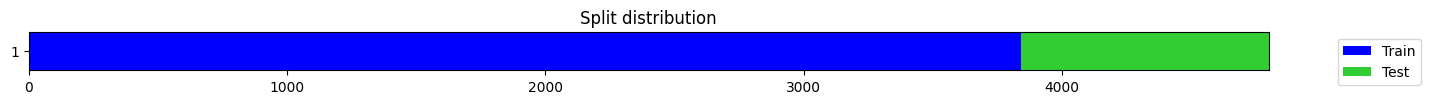

In [5]:
check_data(X, y, splits)

In [6]:
tfms  = [None, [TSRegression()]]
batch_tfms = TSStandardize(by_sample=True, by_var=True)
dls = get_ts_dls(X, y, splits=splits, tfms=tfms, batch_tfms=batch_tfms, bs=BATCH_SIZE, shuffle_train=False, drop_last=False)
dls.one_batch()

(TSTensor(samples:16, vars:1, len:10, device=cpu, dtype=torch.float32),
 tensor([ 0.0195,  0.0449,  0.0312,  0.0156,  0.0410,  0.9141, -0.2500, -0.3340,
         -0.4981, -0.0293, -0.0098,  0.0000, -0.0098,  0.0312,  1.4746, -0.1699]))

For this to work we need to assert that there is only one class - that this is a regression problem. We also want to assert that all batch sizes are greater than 0. Otherwise, the model training will fail.

In [7]:
assert dls.c == 1

for i, b in enumerate(dls.valid):
    xb, yb = b
    assert xb.shape[0] > 0

In order to find the right learning rate for the ML model, we employ fastai's learner. 
They have a ts_learner (time series learner) that can run for 50 epochs with different metrics
to find the learning rate for the specific model. 
The learning rate is found by analysing the graph. The point with the fastest decrease in loss
is the highest learning rate. This value must be used in learn.fit_one_cycle()

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

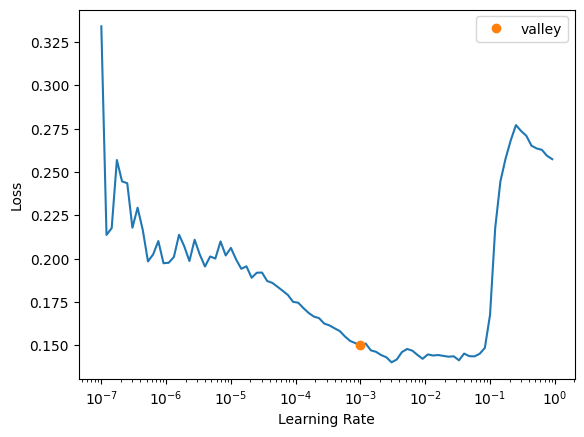

In [8]:
learn = ts_learner(dls, CHOSEN_MODEL, metrics=[mae, rmse], cbs=ShowGraph())
lr_finder = learn.lr_find()

In [9]:
print(learn.dls.valid_ds)
print(learn.dls.valid_ds.tls)

(#960) [(TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(-0.2402)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(-0.3086)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(-0.4981)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(-0.0352)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(-0.0098)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(-0.0098)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(-0.0137)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(0.0195)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(1.5000)), (TSTensor(vars:1, len:10, device=cpu, dtype=torch.float32), tensor(-0.1836))] ...]
[NoTfmLists: ndarray(960, 1, 10), TSTfmdLists: [-0.24023   -0.30859   -0.49805   -0.035156  -0.0097656 -0.0097656
 -0.013672   0.019531   1.5       -0.18359   -0.24414   -0.49805
 -0.12891   -0.0097656 -0.0136

The loss decreases at the beginning, then it stops and it goes back increasing, usually extremely quickly. That's because with very low learning rates, we get better and better, especially since we increase them. Then comes a point where we reach a value that's too high and the phenomenon shown before happens. Looking at this graph, what is the best learning rate to choose? Not the one corresponding to the minimum.

Why? Well the learning rate that corresponds to the minimum value is already a bit too high, since we are at the edge between improving and getting all over the place. We want to go one order of magnitude before, a value that's still aggressive (so that we train quickly) but still on the safe side from an explosion. In the example described by the picture above, for instance, we don't want to pick 10−1 but rather 10−2.

This method can be applied on top of every variant of SGD, and any kind of network. We just have to go through one epoch (usually less) and record the values of our loss to get the data for our plot.
Source: https://sgugger.github.io/how-do-you-find-a-good-learning-rate.html

In [10]:
lrs = learn.recorder.lrs
losses = learn.recorder.losses
sma = 20
derivatives = [0]*(sma+1)

for i in range(1+sma, len(lrs)):
    d = (losses[i] - losses[i-sma]) / sma
    derivatives.append(d)

derivatives = np.array(derivatives)

best_idx = derivatives.argmin()
best_lr = lrs[best_idx]

print("Best LR:", best_lr)

Best LR: 0.0002754228703338166


We use the calculated best learning rate to train the model. Currently hardcoded to 50 epochs.

epoch,train_loss,valid_loss,mae,_rmse,time
0,0.130239,0.073874,0.203683,0.271798,00:09
1,0.031248,0.031657,0.107273,0.177924,00:09
2,0.019185,0.023655,0.092324,0.153802,00:10
3,0.014761,0.020468,0.077691,0.143068,00:10
4,0.012151,0.026094,0.085351,0.161537,00:09
5,0.011315,0.024783,0.078244,0.157426,00:09
6,0.010293,0.015733,0.065758,0.125430,00:11
7,0.011059,0.025021,0.070732,0.158182,00:09
8,0.009521,0.017528,0.085665,0.132394,00:09
9,0.007450,0.011458,0.056990,0.107040,00:08


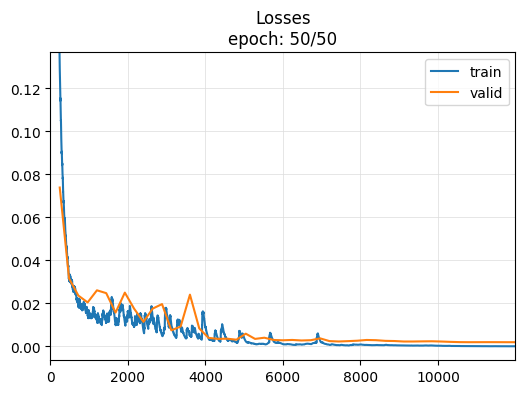

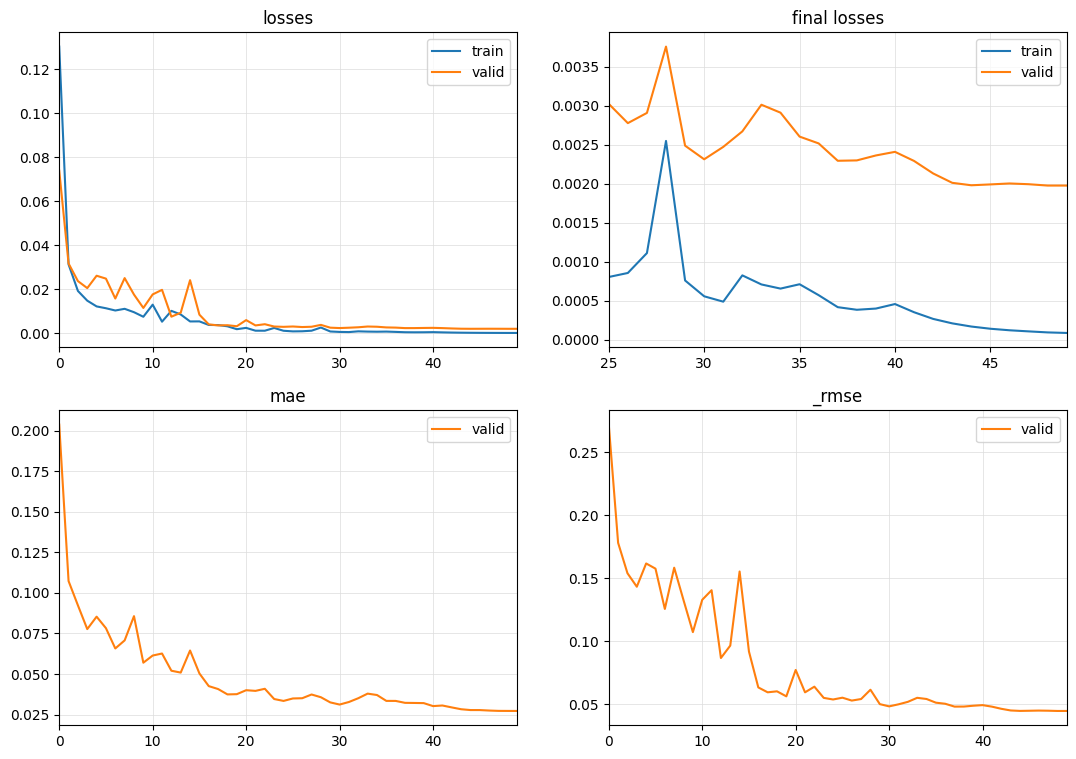

In [11]:
learn = ts_learner(dls, InceptionTime, metrics=[mae, rmse], cbs=ShowGraph())
learn.fit_one_cycle(50, best_lr)

We save the model in it's own path so that it can later be used on different test data for inferring. We need to know the RMSE and model name to evaluate the model on the test data.

In [12]:
_, _, rmse_val = learn.validate() # type: ignore
rmse_val

not enough values to plot a chart


0.044439926743507385

In [13]:
assert isinstance(rmse_val, float)
PATH = Path(f"./models/regression_{DATASET}_dim{DIMENSION}_rmse{round(rmse_val, 5)}_{str(CHOSEN_MODEL.__name__)}.pkl")
PATH.parent.mkdir(parents=True, exist_ok=True)
learn.export(PATH)

In [14]:
del learn